<a href="https://colab.research.google.com/github/jurados/KBMOD-StampNet/blob/main/KBMOD-StampNets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

# KBMOD Coadd Stamps

## README

The following data was generated for use as part of the [KBMOD](https://github.com/dirac-institute/kbmod) project, for the purpose of creating a machine learning model to filter out false positve results from the KBMOD search. The data set is divided into two sets of data, the true positive and false positive, with each set also divided into the training, validation, and test sets for ML purposes.

### True Positive

This dataset was generated based on the synthetic objects inserted into the DEEP data by Pedro Bernardinelli, and then cutout from the survey dataset by Steven Stetzler. The original stamp cutouts are available on hyak at `/gscratch/dirac/DEEP/collab/fakes_cutouts/data/*/npy` (the `*` being the id of the fake object in DEEP).

### False Positive

This dataset was generated by running KBMOD on the DEEP data, but setting the set of serach angles to be roughly perpendicular to the ecliptic. This allows us to semi-safely assume that any search results are not real or inserted objects (i.e., while some real or synthetic objects may have been included in this set, the ratio to bad results is small enough to not be of concern for machine learning purposes).

### Data Transformation

Each source observation in the above set was ran through a series of random transformations, to enlarge the dataset and to capture all possible features of both sets. Those transformations were:
- select a random subset of the total set to coadd, with a minimum number of observations set to 25
    - so if the N number of observations is > 25 then the set of stamps used in coadding is of length [25,N]
- potentially offset the center pixel of each stamp by one in either direction, for both the X and Y in pixel space
    - so the set x_offset = [-1, 0, 1] and y_offset = [-1, 0, 1], creating nine potential offset states around the "actual" center of the object/results.
- potentially mirror around both the x and y axis
- potentially rotate 90 degrees around the center N times, where N is [0-3]

### Data Format

The data arrays are stored as numpy `.npy` files, and can be loaded with `x = np.load(PATH)`.

The shape of the data is `(N, 3, 21, 21)`, where N is the number of individual stamps in each set. The second dimmension corresponds to the type of coadd performed.
- index 0 = median coadd stamp
- index 1 = mean coadd stamp
- index 2 = sum coadd stamp.
Side note: the true positive stamp files also have an index 3, which corresponds to the recently added variance weighted coadd stamps. However, we found some discrepancies in those stamps and decided not to generate them for the false positive stamp. You can filter out this fourth column from the true positive set by slicing the array like [:,:3,:,:].

Each coadd stamp has the shape (21,21).

## Data

Here are the preloaded data sets. If you want to generate your own train, test, and validation sets, you can load in the `true_positive_stamps_full.npy` and `false_positive_stamps_full.npy` files.

In [3]:
from google.colab import drive, files
drive.mount('/content/gdrive', force_remount=True)
%cd "/content/gdrive/MyDrive/(POSGRADO) Universidad de Chile/ELECTIVE - Astroinformatic/Project"

Mounted at /content/gdrive
/content/gdrive/MyDrive/(POSGRADO) Universidad de Chile/ELECTIVE - Astroinformatic/Project


In [4]:
data_dir = "./kbmodstamps/"

# TRUE POSITVE PATHS
true_pos_full  = os.path.join(data_dir, "true_positive_stamps_full.npy")
true_pos_train = os.path.join(data_dir, "true_train_stamps.npy")
true_pos_valid = os.path.join(data_dir, "true_valid_stamps.npy")
true_pos_test  = os.path.join(data_dir, "true_test_stamps.npy")

# FALSE POSITVE PATHS
false_pos_full  = os.path.join(data_dir, "false_positive_stamps_full.npy")
false_pos_train = os.path.join(data_dir, "false_train_stamps.npy")
false_pos_valid = os.path.join(data_dir, "false_valid_stamps.npy")
false_pos_test  = os.path.join(data_dir, "false_test_stamps.npy")

In [5]:
# this indexing isn't strictly needed if you're just grabbing one of the other coadd type columns, see below cell.
true_train = np.load(true_pos_train)[:,:3,:,:]
true_val   = np.load(true_pos_valid)[:,:3,:,:]
true_test  = np.load(true_pos_test)[:,:3,:,:]

false_train = np.load(false_pos_train)
false_val   = np.load(false_pos_valid)
false_test  = np.load(false_pos_test)
true_train.shape, false_train.shape

((129010, 3, 21, 21), (110530, 3, 21, 21))

In [6]:
true_train_median = true_train[:,0,:,:]
true_val_median   = true_val[:,0,:,:]
true_test_median  = true_test[:,0,:,:]

false_train_median = false_train[:,0,:,:]
false_val_median   = false_val[:,0,:,:]
false_test_median  = false_test[:,0,:,:]

print(f"Train -> True: {true_train_median.shape} | False: {false_train_median.shape}")
print(f"Valid -> True: {true_val_median.shape} | False: {false_val_median.shape}")
print(f"Test  -> True: {true_test_median.shape}  | False: {false_test_median.shape}")

Train -> True: (129010, 21, 21) | False: (110530, 21, 21)
Valid -> True: (36860, 21, 21) | False: (31580, 21, 21)
Test  -> True: (18430, 21, 21)  | False: (15790, 21, 21)


## Visualization

If you want to visualize what certain stamps look like, you can use `plt.imshow` and pass in the desired row.

Side note on visualizing the true positive stamps: we specifically weakened the signal on some of the observations to simulate a wider range of data. Visualizing some of the stamps might seem like mostly random noise, but I do promise there is signal there. Some of the time the PSF isn't visible in the median stamp but is seen in the mean or sum, or vice versa. I'm still messing around with the dataset so if we're running into too much low-SNR contimination in this set, we can raise the minimum observations in the selection algorithm and rerun everything, it only takes about 20 minutes to do :

In [7]:
def plot_true_false(true, false, nimgs=10, ncols=5, cmap='gray', donorm=False, savefig=False):
        """
        Plots a random sample of True and False cutout stamps with individual colorbars.

        Parameters:
        -----------
        - true : np.ndarray
            Array containing True positive cutout stamps (shape: [N, H, W]).
        - false : np.ndarray
            Array containing False positive cutout stamps (shape: [N, H, W]).
        - nimgs : int, default=10
            Number of random images to display for each class.
        - ncols : int, default=5
            Number of columns for organizing the subplot grid.
        - cmap : str, default='gray'
            Matplotlib colormap used to render pixel intensities.
        - savefig : bool, default=False
            If True, saves both figures as PNG files to disk.
        """
        # Dynamically compute grid dimensions
        ncols = min(nimgs, ncols)
        nrows = int(np.ceil(nimgs / ncols))

        # 3.0 de ancho por columna da espacio holgado para imagen + colorbar + etiquetas
        figsize = (3.0 * ncols, 2.6 * nrows)

        idx_true  = np.random.choice(len(true), nimgs, replace=False)
        idx_false = np.random.choice(len(false), nimgs, replace=False)

        # Definimos espaciados constantes para que ambas figuras sean idénticas
        grid_params = {'wspace': 0.35, 'hspace': 0.35}

        # ------------------ 1. TRUE POSITIVES FIGURE ------------------
        fig_0, ax_0 = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize,
                                   squeeze=False, gridspec_kw=grid_params)
        ax_0 = ax_0.flatten()
        for i in range(len(ax_0)):
            if i < nimgs:
                im = ax_0[i].imshow(true[idx_true[i]], cmap=cmap)
                ax_0[i].set_title(f"ID: {idx_true[i]}", fontsize=10, pad=6)
                fig_0.colorbar(im, ax=ax_0[i], fraction=0.046, pad=0.04)
            ax_0[i].axis('off')

        # y=0.98 a 1.05 con top=0.88 deja un margen limpio sin solapamientos
        fig_0.suptitle(f'True Stamps (n={nimgs})', fontsize=14, y=0.98)

        # ------------------ 2. FALSE POSITIVES FIGURE ------------------
        fig_1, ax_1 = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize,
                                   squeeze=False, gridspec_kw=grid_params)
        ax_1 = ax_1.flatten()
        for i in range(len(ax_1)):
            if i < nimgs:
                im = ax_1[i].imshow(false[idx_false[i]], cmap=cmap)
                ax_1[i].set_title(f"ID: {idx_false[i]}", fontsize=10, pad=6)
                fig_1.colorbar(im, ax=ax_1[i], fraction=0.046, pad=0.04)
            ax_1[i].axis('off')

        fig_1.suptitle(f'False Stamps (n={nimgs})', fontsize=14, y=0.98)

        suffix = '_norm' if donorm else ''

        if savefig:
            fig_0.savefig(f'true_stamps{suffix}.png', bbox_inches='tight')
            fig_1.savefig(f'false_stamps{suffix}.png', bbox_inches='tight')
            files.download(f'true_stamps{suffix}.png')
            files.download(f'false_stamps{suffix}.png')

        plt.show()

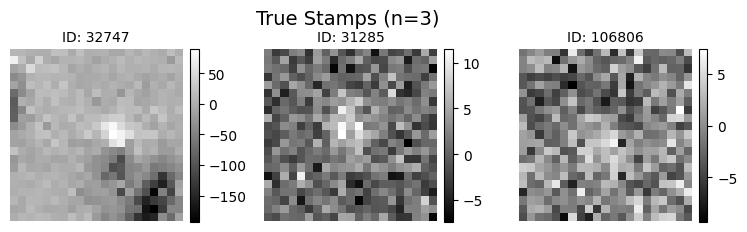

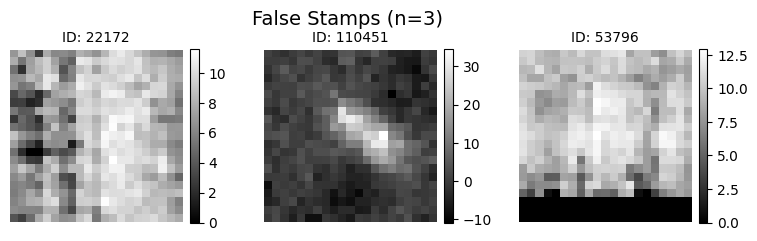

In [8]:
plot_true_false(true_train[:,0,:,:], false_train[:,0,:,:], nimgs=3, cmap='gray', savefig=False)

We want to see how the intensity is distributed across all training images (`X_train`) to evaluate and select the most appropriate normalization pipeline for our machine learning models.
  
Astronomical coadd cutouts typically exhibit a vast dynamic range:
* **Background Noise Pedestal:** The vast majority of pixels correspond to Gaussian sky background fluctuations centered near zero.
* **Heavy-tailed Outliers:** Saturated stars, cosmic rays, and injected synthetic sources create long tails spanning orders of magnitude higher than the noise level.             

To properly preprocess these data without allowing extreme outliers to destabilize gradient descent during training, we compare three representations:
  
1. **Raw Data (Original):** The unscaled pixel intensity values clipped between the 1st and 99th percentiles ($p_1, p_{99}$) on a logarithmic count scale to reveal both the background noise and the fainter emission wings.
2. **Robust SNR Scaling (Sigma-clipped):** The data scaled to Signal-to-Noise Ratio (SNR) units by subtracting the robust background median and dividing by the noise dispersion ($\sigma_{\text{bg}}$) estimated via `astropy.stats.sigma_clipped_stats`. This standardizes the sky background to zero with unit variance ($\sigma \approx 1$).
3. **SNR + Arcsinh Compression:** A non-linear stretch using the inverse hyperbolic sine ($\operatorname{arcsinh}$, Lupton et al., 1999). This transformation preserves linearity for background noise fluctuations near zero ($\operatorname{arcsinh}(x) \approx x$) while smoothly compressing bright fluxes logarithmically ($\operatorname{arcsinh}(x) \approx \ln(2x)$), avoiding artificial saturation clipping while maintaining bounded, well-behaved features for our models.

In [9]:
from astropy.stats import sigma_clipped_stats

Background signal: 0.00 | Noise (sigma): 6.69


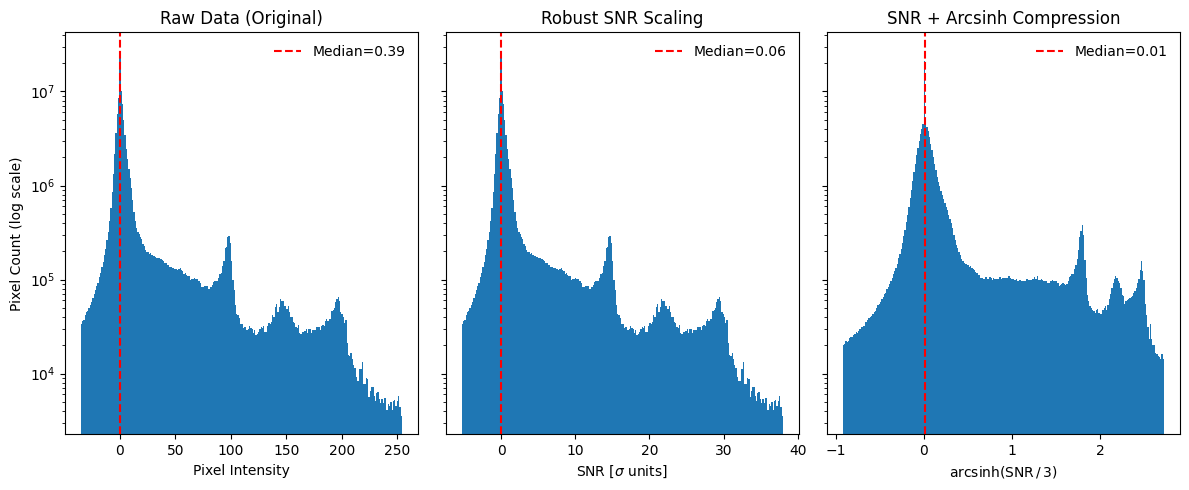

In [10]:
def normalization(data, only_sigma_clipping=False, sigma=3.0, scale_factor=3.0, verbose=False, savefig=True):
    """
    Normalize astronomical image data using robust sigma-clipped statistics
    and an optional non-linear inverse hyperbolic sine (arcsinh) stretch.

    This function centers the sky background around zero and scales the noise
    dispersion to unit variance (SNR scale). Optionally, it compresses the high
    dynamic range using the arcsinh transformation (Lupton et al., 1999).

    Parameters:
    ---------
    - data : `~np.ndarray`
        Input array containing astronomical stamps (e.g., shape `(N, H, W)`
        or `(N, C, H, W)`).
    - only_sigma_clipping : bool, default=False
        If True, only applies robust background subtraction and standard deviation
        scaling (Z-score / SNR units):
                `data_norm = (data - median_bg) / std_bg`
        If False, applies the non-linear `arcsinh` dynamic range compression
        on top of the sigma-clipped background scaling.
    - sigma:

    Returns:
    --------
    - `np.ndarray`
        Normalized array matching the shape and dimensions of `data`:
        - If `only_sigma_clipping=True`: Data scaled to units of Signal-to-Noise
        Ratio (SNR), centered at the sky background with unit noise standard deviation.
        - If `only_sigma_clipping=False`: High dynamic range compressed data
        via `arcsinh`, well-suited for gradient-based machine learning models.

    References:
    -----------
    Lupton, R., Blanton, M. R., Fekete, G., et al. (1999).
    "A Modified Magnitude System that Produces Well-Behaved Magnitudes,
    Colors, and Errors Even for Negative Flux". The Astronomical Journal, 118(3), 1406.
    """

    mean_bg, median_bg, std_bg = sigma_clipped_stats(data, sigma=sigma)
    if std_bg == 0 or np.isnan(std_bg): std_bg = 1.0
    if verbose:
        print(f"Background signal: {median_bg:.2f} | Noise (sigma): {std_bg:.2f}")

    data_snr = (data - median_bg) / std_bg

    if only_sigma_clipping: return data_snr
    else: return np.arcsinh(data_snr / scale_factor)

X_train = np.concatenate([true_train_median, false_train_median])
p1, p99 = np.percentile(X_train, [1, 99])
median  = np.median(X_train)

X_train_snr   = normalization(X_train, only_sigma_clipping=True, verbose=True)
X_train_asinh = normalization(X_train, only_sigma_clipping=False, scale_factor=5.0)
p1_snr, p99_snr     = np.percentile(X_train_snr, [1, 99])
p1_asinh, p99_asinh = np.percentile(X_train_asinh, [1, 99])

median_snr    = np.median(X_train_snr)
median_asinh  = np.median(X_train_asinh)

fig, axes = plt.subplots(ncols=3, figsize=(12,5), sharey=True)

axes[0].hist(X_train.flatten(), bins=250, range=(p1, p99))
axes[0].axvline(median, color='r', linestyle='--', label=f'Median={median:.2f}')
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Pixel Count (log scale)")
axes[0].set_title("Raw Data (Original)")

axes[1].hist(X_train_snr.flatten(), bins=250, range=(p1_snr, p99_snr))
axes[1].axvline(median_snr, color='r', linestyle='--', label=f'Median={median_snr:.2f}')
axes[1].set_xlabel(r"SNR [$\sigma$ units]")
axes[1].set_title("Robust SNR Scaling")

axes[2].hist(X_train_asinh.flatten(), bins=250, range=(p1_asinh, p99_asinh))
axes[2].axvline(median_asinh, color='r', linestyle='--', label=f'Median={median_asinh:.2f}')
axes[2].set_xlabel(r"$\operatorname{arcsinh}(\mathrm{SNR} \,/\, 3)$")
axes[2].set_title("SNR + Arcsinh Compression")

for ax in axes:
    ax.set_yscale("log")
    ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("normalization.png")
#files.download("normalization.png")
plt.show()

Below are representative examples of cutout stamps after applying the robust $\operatorname{arcsinh}$ normalization. Notice how the non-linear stretch preserves the profile of bright sources while maintaining the noise structure of the sky background.

Background: 0.00 | Noise (sigma): 6.69


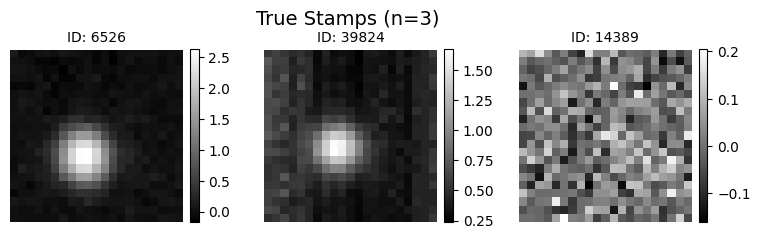

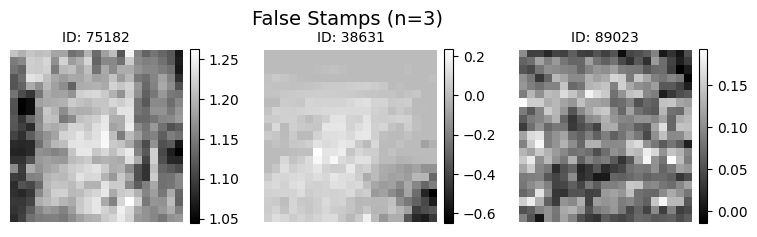

In [11]:
# 1. Estadísticas globales: SOLO train, ambas clases juntas
X_train_all = np.concatenate([true_train_median, false_train_median], axis=0)
_, median_bg, std_bg = sigma_clipped_stats(X_train_all, sigma=3.0)
print(f"Background: {median_bg:.2f} | Noise (sigma): {std_bg:.2f}")

beta = 5.0  # scale_factor

# 2. Misma transformación para todos los splits y clases
true_train_median  = np.arcsinh((true_train_median  - median_bg) / std_bg / beta)
true_val_median    = np.arcsinh((true_val_median    - median_bg) / std_bg / beta)
true_test_median   = np.arcsinh((true_test_median   - median_bg) / std_bg / beta)

false_train_median = np.arcsinh((false_train_median - median_bg) / std_bg / beta)
false_val_median   = np.arcsinh((false_val_median   - median_bg) / std_bg / beta)
false_test_median  = np.arcsinh((false_test_median  - median_bg) / std_bg / beta)

plot_true_false(true_train_median, false_train_median, nimgs=3, donorm=True, savefig=False)

In [12]:
%%capture
try:
    import lightning as L
except:
    !pip install lightning

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("logs/")

from torchvision import transforms
import torchvision.transforms.functional as TF
from torchsummary import summary
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassF1Score,
    MulticlassPrecision,
    MulticlassRecall,
)

import lightning as L

from tqdm.auto import tqdm

device ='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

[Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)

Shape:
- Input:  $(N,C_{in},H_{in}, W_{in})$ or $(C_{in},H_{in}, W_{in})$
- Output: $(N,C_{out},H_{out}, W_{out})$ or $(C_{out},H_{out}, W_{out})$

Parameters:
- `in_channels`
- `out_channels`
- `kernel_size`
- `stride`: Default value is 1.
- `padding`: Default value is 0.
- `dilation`: Default value is 1.
- `groups`: controls the connections between inputs and outputs.
- `bias`: If `True`, adds a learnable bias to the output.
- `padding_mode`


$$ H_{out}=\left[\frac{H_{in}+2 \times \text{padding}[0]-\text{dilation}[0] \times (\text{kernel_size}[0]- 1)- 1}{\text{stride}[0]} +1 \right]
$$
$$ W_{out}=\left[\frac{W_{in}+2 \times \text{padding}[1]-\text{dilation}[1] \times (\text{kernel_size}[1]- 1)- 1}{\text{stride}[0]} +1 \right]
$$

Parameters:
- `kernel_size`
- `stride`: Default value is `kernel_size`.
- `padding`
- `dilation`
- `return_indices`: If `True`, will return te max indices along with the outputs. Useful for `torch.nn.MaxUnpool2d` later.
- `ceil_mode`: when `True`, will use _ceil_ instead of _floor_ to compute the output shape.


[`MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

Shape:
- Input:  $(N,C,H_{in}, W_{in})$ or $(C,H_{in}, W_{in})$
- Output: $(N,C,H_{out}, W_{out})$ or $(C,H_{out}, W_{out})$

Parameters:
- `kernel_size`
- `stride`: Default value is `kernel_size`.
- `padding`
- `dilation`
- `return_indices`: If `True`, will return te max indices along with the outputs. Useful for `torch.nn.MaxUnpool2d` later.
- `ceil_mode`: when `True`, will use _ceil_ instead of _floor_ to compute the output shape.

$$ H_{out}=\left[\frac{H_{in}+2 \times \text{padding}[0]-\text{dilation}[0] \times (\text{kernel_size}[0]- 1)- 1}{\text{stride}[0]} +1 \right]
$$
$$ W_{out}=\left[\frac{W_{in}+2 \times \text{padding}[1]-\text{dilation}[1] \times (\text{kernel_size}[1]- 1)- 1}{\text{stride}[0]} +1 \right]
$$

### Model V0: Basic

I've included a simple model here as jumping off point. Go wild

In [14]:
class Basic(L.LightningModule):
    def __init__(self, num_classes):
        """
        Parameters:
        -----------
        - n_classes: int
            Number of classes to predict
        """

        super().__init__()
        #self.save_hyperparameters()
        self.feature_extractor = nn.Sequential(
            # Input (Cin=1, Hin=21, Win=21, kenel_size=3, stride=1, padding=0, dilation=1)
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3),
            # Output (Cout=8, Hin=18, Win=18)
            nn.BatchNorm2d(num_features=8),
            # Output (Cout=8, Hin=18, Win=18)
            nn.ReLU(),
            # Output (Cout=8, Hin=18, Win=18)
            nn.MaxPool2d(kernel_size=2),
            # Output (Cout=8, Hin=9, Win=9)
            nn.Dropout(p=0.25),
            # Output (Cout=8, Hin=9, Win=9)
            nn.Flatten(),
            # Output (8*9*9)
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=8*9*9, out_features=64),
            # Output (64)
            nn.ReLU(),
            # Output (64)
            nn.Dropout(p=0.5),
            # Output (64)
            nn.Linear(in_features=64, out_features=num_classes),
            # Output (n_classes)
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        if x.dim == 3: x.unsqueeze(1)
        features = self.feature_extractor(x)
        logits   = self.classifier(features)
        return logits

model = Basic(num_classes=2).to(device) # Move the model to the GPU
summary(model, (1, 21, 21))           # Now call summary

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 19, 19]              80
       BatchNorm2d-2            [-1, 8, 19, 19]              16
              ReLU-3            [-1, 8, 19, 19]               0
         MaxPool2d-4              [-1, 8, 9, 9]               0
           Dropout-5              [-1, 8, 9, 9]               0
           Flatten-6                  [-1, 648]               0
            Linear-7                   [-1, 64]          41,536
              ReLU-8                   [-1, 64]               0
           Dropout-9                   [-1, 64]               0
           Linear-10                    [-1, 2]             130
Total params: 41,762
Trainable params: 41,762
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.16
Estimated Tot

### Model V1: ResNet-56

In [15]:
class ResidualBlock(nn.Module):
    """
    Basic Residual Block for Deep Residual Networks (ResNet), based on He et al. (2015).

    Parameters:
    -----------
    - in_channels : int
        Number of input feature channels.
    - out_channels : int
        Number of output feature channels produced by the block.
    - stride : int, default=1
        Stride of the first 3x3 convolution. A stride > 1 downsamples the spatial
        dimensions (Height and Width).

    References:
    -----------
    He, K., Zhang, X., Ren, S., & Sun, J. (2016).
    "Deep Residual Learning for Image Recognition".
    Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR).
    """

    def __init__(self, in_channel, out_channel, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channel, out_channel, kernel_size=3, padding=1, stride=stride)
        self.bn1   = nn.BatchNorm2d(out_channel)
        self.conv2 = nn.Conv2d(out_channel, out_channel, kernel_size=3, padding=1, stride=1)
        self.bn2   = nn.BatchNorm2d(out_channel)

        if stride != 1 or in_channel != out_channel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channel, out_channel, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channel)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self,x):
        identity = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        out = F.relu(out)

        return out


class ResNet56(nn.Module):
    """
    ResNet-56 architecture for small images based on He et al. (2016).

    Designed following the CIFAR-style ResNet topology:
    - An initial 3x3 convolution with 16 filters.
    - Three stages of residual blocks (each containing $n$ blocks of 2 convolutions each):
        - Stage 1: 16 channels, feature map size $21 \times 21$ ($n$ blocks)
        - Stage 2: 32 channels, feature map size $11 \times 11$ ($n$ blocks, stride=2)
        - Stage 3: 64 channels, feature map size $6 \times 6$ ($n$ blocks, stride=2)
    - Global Adaptive Average Pooling ($1 \times 1$).
    - Final Fully Connected classification layer producing unnormalized log-probabilities (logits).

    Total convolutional layers = $1 + 2 \times 3n + 1 = 6n + 2$.
    With $n = 9$, the network has exactly 56 layers.

    Parameters:
    -----------
    - n : int, default=9
        Number of residual blocks per stage ($6n + 2$ total depth). For ResNet-56, $n=9$.
    - num_classes : int, default=2
        Number of output classes (e.g., 2 for binary classification: True vs False positives).
    - in_channels : int, default=1
        Number of input channels (1 for median coadd stamps).

    References:
    -----------
    He, K., Zhang, X., Ren, S., & Sun, J. (2016).
    "Deep Residual Learning for Image Recognition".
    Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR).
    """

    def __init__(self, n=9, num_classes=2):
        super().__init__()

        # Initial Convolution
        self.conv1  = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1    = nn.BatchNorm2d(16)

        # Three steps of residualblocks (16 -> 32 -> 64 channels)
        self.block1 = self.residual_block(n=n, in_channel=16, out_channel=16, stride=1)
        self.block2 = self.residual_block(n=n, in_channel=16, out_channel=32, stride=2)
        self.block3 = self.residual_block(n=n, in_channel=32, out_channel=64, stride=2)

        # Classifier
        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc       = nn.Linear(64, num_classes)

    def residual_block(self, n, in_channel, out_channel, stride):
        block = [ResidualBlock(in_channel, out_channel, stride)]
        for _ in range(n-1):
            block.append(ResidualBlock(out_channel, out_channel, stride=1))
        return nn.Sequential(*block)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)

        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)

        logits = self.fc(out)
        return logits

model = ResNet56().to(device)   # Move the model to the GPU
summary(model, (1, 21, 21))  # Now call summary

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 21, 21]             160
       BatchNorm2d-2           [-1, 16, 21, 21]              32
          Identity-3           [-1, 16, 21, 21]               0
            Conv2d-4           [-1, 16, 21, 21]           2,320
       BatchNorm2d-5           [-1, 16, 21, 21]              32
            Conv2d-6           [-1, 16, 21, 21]           2,320
       BatchNorm2d-7           [-1, 16, 21, 21]              32
     ResidualBlock-8           [-1, 16, 21, 21]               0
          Identity-9           [-1, 16, 21, 21]               0
           Conv2d-10           [-1, 16, 21, 21]           2,320
      BatchNorm2d-11           [-1, 16, 21, 21]              32
           Conv2d-12           [-1, 16, 21, 21]           2,320
      BatchNorm2d-13           [-1, 16, 21, 21]              32
    ResidualBlock-14           [-1, 16,

### Model V2: ResNet-50

In our implementation, the structural hyperparameters for **ResNet-50** are defined as:
  
```python
model_parameters['resnet50'] = ([64, 128, 256, 512], [3, 4, 6, 3], 4, True)
```
  
This tuple `(base_channels, repetitions, expansion_factor, use_bottleneck)` governs the network backbone as follows:
  
* **`[64, 128, 256, 512]` (`base_channels`):** Specifies the base number of intermediate feature filters across each of the 4 residual stages.
* **`[3, 4, 6, 3]` (`repetitions`):** Defines the number of residual blocks stacked within each respective stage.
* **`4` (`expansion_factor`):** The channel multiplication factor applied at the output of every Bottleneck block:
    - Stage 1: $64 \rightarrow 64 \times 4 = \mathbf{256}$ channels
    - Stage 2: $128 \rightarrow 128 \times 4 = \mathbf{512}$ channels
    - Stage 3: $256 \rightarrow 256 \times 4 = \mathbf{1024}$ channels
    - Stage 4: $512 \rightarrow 512 \times 4 = \mathbf{2048}$ channels
* **`True` (`use_bottleneck`):** Enables the 3-layer **Bottleneck** block design ($1\times1 \rightarrow 3\times3 \rightarrow 1\times1$). This is set to `True` exclusively for deep ResNet variants (ResNet-50, 101, and 152) to control computational cost, whereas shallower models (ResNet-18 and 34) set this to `False` to use 2-layer BasicBlocks.           
  
#### Layer Count Breakdown (50 Total Layers):
$$\text{Total Layers} = \underbrace{1}_{\text{Conv1}} + \underbrace{3 \times (3 + 4 + 6 + 3)}_{\text{Bottleneck Convolutions}} + \underbrace{1}_{\text{Linear (FC)}} = \mathbf{50 \text{ layers}}$$


In [16]:
# This model is upload
import torchvision

class ResNet50(L.LightningModule):
    def __init__(self, num_classes):
        super().__init__()
        self.resnet50 = torchvision.models.resnet50(weights="DEFAULT")

        # Dont change the parameters
        # Keep without change the parameters
        for param in self.resnet50.parameters():
            param.requires_grad = False

        self.resnet50.conv1 = nn.Conv2d(
            in_channels=1, out_channels=self.resnet50.conv1.out_channels,
            kernel_size=self.resnet50.conv1.kernel_size, stride=self.resnet50.conv1.stride,
            padding=self.resnet50.conv1.padding, bias=False) # change input channels to 21

        self.resnet50.fc = nn.Linear(in_features=self.resnet50.fc.in_features, out_features=num_classes)
        self.activation = nn.Sigmoid() if num_classes == 1 else nn.Softmax(dim=1)


    def forward(self, x):
        x = x.view(x.size(0), 1, 21, 21)
        y = self.resnet50(x)
        #y = self.activation(y)
        return y

model = ResNet50(num_classes=2).to(device=device)
summary(model, (1, 21, 21))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 11, 11]           3,136
       BatchNorm2d-2           [-1, 64, 11, 11]             128
              ReLU-3           [-1, 64, 11, 11]               0
         MaxPool2d-4             [-1, 64, 6, 6]               0
            Conv2d-5             [-1, 64, 6, 6]           4,096
       BatchNorm2d-6             [-1, 64, 6, 6]             128
              ReLU-7             [-1, 64, 6, 6]               0
            Conv2d-8             [-1, 64, 6, 6]          36,864
       BatchNorm2d-9             [-1, 64, 6, 6]             128
             ReLU-10             [-1, 64, 6, 6]               0
           Conv2d-11            [-1, 256, 6, 6]          16,384
      BatchNorm2d-12            [-1, 256, 6, 6]             512
           Conv2d-13            [-1, 256, 6, 6]          16,384
      BatchNorm2d-14            [-1, 25

### Training and Validation

In [17]:
def dataloader(Falses, Trues, batch_size=64, shuffle=True, random_seed=42, verbose=False):
    X = np.concatenate([Falses, Trues], axis=0)
    # Lables: 0 falses, 1 trues
    y = np.concatenate([np.zeros(len(Falses)), np.ones(len(Trues))])

    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1) # shape:(N, 1, 21, 21)
    y_tensor = torch.tensor(y, dtype=torch.long)
    if verbose:
        print(f"Dataset summary -> X: {tuple(X_tensor.shape)} | y: {tuple(y_tensor.shape)} | Clases: {torch.unique(y_tensor).tolist()}")

    dataset    = TensorDataset(X_tensor, y_tensor)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return loader

print("--- Training Set ---")
train_dataloader = dataloader(false_train_median, true_train_median, batch_size=512, shuffle=True, verbose=True)

print("\n--- Validation Set ---")
val_dataloader   = dataloader(false_val_median, true_val_median, batch_size=512, shuffle=False, verbose=True)

print("\n--- Test Set ---")
test_dataloader  = dataloader(false_test_median, true_test_median, batch_size=512, shuffle=False, verbose=True)

--- Training Set ---
Dataset summary -> X: (239540, 1, 21, 21) | y: (239540,) | Clases: [0, 1]

--- Validation Set ---
Dataset summary -> X: (68440, 1, 21, 21) | y: (68440,) | Clases: [0, 1]

--- Test Set ---
Dataset summary -> X: (34220, 1, 21, 21) | y: (34220,) | Clases: [0, 1]


### Rotational and Reflectional Symmetries: The Dihedral Group $D_4$
  
Because our cutout stamps are square images of size $21 \times 21$, their underlying spatial symmetry group is the **dihedral group of degree 4**, denoted as $D_4$ (having order $|D_4| = 8$).
  
#### 1. Group Presentation
From abstract algebra, $D_4$ can be generated by two fundamental elements: an orthogonal rotation $r$ by $90^\circ$ and a reflection $s$:

$$\langle r, s \mid r^4 = e, \; s^2 = e, \; s r s = r^{-1} \rangle$$
where $e$ denotes the identity element. Every symmetry operation in $D_4$ is uniquely expressed as $r^k s^m$, with $k \in \{0, 1, 2, 3\}$ and $m \in \{0, 1\}$.
  
#### 2. Symmetry Elements Table
The 8 isometric transformations acting on the image coordinate plane are summarized below:

| Element ($g \in D_4$) | Geometric Description | Matrix Representation $[x, y]^T$ | Order ($|g|$) | Action on Image Coordinates $(u, v)$ |
| :---: | :--- | :---: | :---: | :---: |
| **$e$** | Identity ($0^\circ$) | $\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$ | $1$ | $(u, v)$ |
| **$r$** | Rotation by $90^\circ$ (counter-clockwise) | $\begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix}$ | $4$ | $(-v, u)$ |
| **$r^2$** | Rotation by $180^\circ$ | $\begin{bmatrix} -1 & 0 \\ 0 & -1 \end{bmatrix}$ | $2$ | $(-u, -v)$ |
| **$r^3$** | Rotation by $270^\circ$ (counter-clockwise) | $\begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix}$ | $4$ | $(v, -u)$ |
| **$s$** | Horizontal flip (reflection across vertical axis) | $\begin{bmatrix} -1 & 0 \\ 0 & 1 \end{bmatrix}$ | $2$ | $(-u, v)$ |
| **$sr$** | Reflection across main diagonal ($y = x$) | $\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$ | $2$ | $(v, u)$ |
| **$sr^2$** | Vertical flip (reflection across horizontal axis) | $\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$ | $2$ | $(u, -v)$ |
| **$sr^3$** | Reflection across anti-diagonal ($y = -x$) | $\begin{bmatrix} 0 & -1 \\ -1 & 0 \end{bmatrix}$ | $2$ | $(-v, -u)$ |
  
#### 3. Astrophysical Motivation and Implementation
In astronomical observation, point sources, moving transients, and diffuse sky backgrounds are isotropic in the celestial plane (there is no preferred directional orientation in space). Therefore, the ground-truth classification function $f: \mathcal{X} \to \mathcal{Y}$ must be invariant under the action of $D_4$:

$$\forall g \in D_4, \quad f(g \cdot x) = f(x)$$
  
By dynamically sampling these 8 group transformations during training via `GPUDataAugmentation`, we expose the neural network to the complete group orbit $\mathcal{O}_x = \{ g \cdot x \mid g \in D_4 \}$ for each cutout stamp, preventing convolutional filters from learning spurious directional biases.


In [18]:
class GPUDataAugmentation(nn.Module):
    r"""
    On-the-fly GPU tensor data augmentation implementing dihedral group $D_4$ symmetries of
    degree 8

    Every element of $D_4$ is uniquely expressed as $g = s^m \circ r^k$, where:
    - $k \in \{0, 1, 2, 3\}$ corresponds to rotations $r^k$ ($0^\circ, 90^\circ, 180^\circ, 270^\circ$).
    - $m \in \{0, 1\}$ corresponds to the reflection generator $s^m$ (horizontal flip).

    References:
    -----------
    Dieleman, S., Willett, K. W., & Dambre, J. (2015).
    "Rotation-invariant convolutional neural networks for galaxy morphology prediction".
    Monthly Notices of the Royal Astronomical Society (MNRAS), 450(2), 1441-1459.
    """

    def __init__(self):
        super().__init__()

    def forward(self, x, fix_k = None, fix_m = None):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)

        if fix_k is not None and fix_m is not None:
            if fix_k > 0: x = torch.rot90(x, k=fix_k, dims=[-2, -1])
            if fix_m == 1: x = TF.hflip(x)
            return x

        if not self.training: return x

        # Rotation Parameter: k in {0, 1, 2, 3} -> r^k
        k = torch.randint(0, 4, (1,)).item()
        if k > 0: x = torch.rot90(x, k=k, dims=[-2, -1])

        # Reflexion Parameter: m in {0, 1} -> s^m
        m = torch.randint(0, 2, (1,)).item()
        if m == 1: x = TF.hflip(x)

        return x

We now illustrate the action of the full dihedral group $D_4$ on an individual cutout stamp, showing the resulting 8 symmetry states generated by varying $(m, k)$:

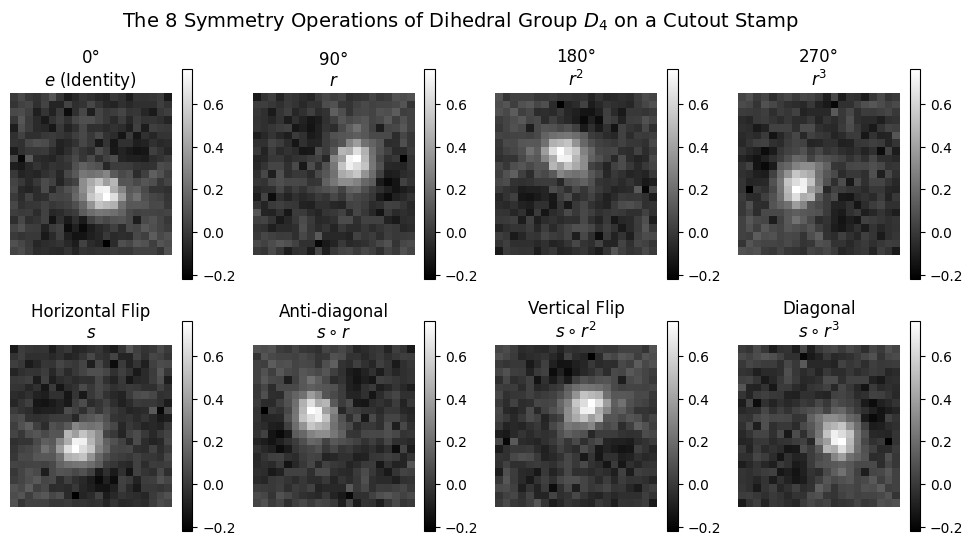

In [19]:
sample_img = true_train_median[2]

aug = GPUDataAugmentation()
elements = [
    # Fila 1: Rotations (m = 0)
    (0, 0, r"$e$ (Identity)", "0°"),
    (0, 1, r"$r$", "90°"),
    (0, 2, r"$r^2$", "180°"),
    (0, 3, r"$r^3$", "270°"),
    # Fila 2: Reflections (m = 1)
    (1, 0, r"$s$", "Horizontal Flip"),
    (1, 1, r"$s \circ r$", "Anti-diagonal"),
    (1, 2, r"$s \circ r^2$", "Vertical Flip"),
    (1, 3, r"$s \circ r^3$", "Diagonal"),
]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i, (m, k, sym_label, desc) in enumerate(elements):
    trans  = aug(sample_img, fix_k=k, fix_m=m)
    img_np = trans.squeeze().cpu().numpy() if isinstance(trans, torch.Tensor) else trans.squeeze()

    im = axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"{desc}\n{sym_label}")
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i])

fig.suptitle(r"The 8 Symmetry Operations of Dihedral Group $D_4$ on a Cutout Stamp", fontsize=14)
plt.savefig('dihedral_group.png', dpi=300)
#files.download('dihedral_group.png')
plt.show()

In [20]:
class StampClassifier(L.LightningModule):
    def __init__(self, num_classes=2, model='basic', lr=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.num_classes = num_classes
        self.lr          = lr

        # Data Augmentation of GPU
        self.augmentation = GPUDataAugmentation()

        if model == 'basic':
            self.model = Basic(num_classes)
        elif model == 'resnet56':
            self.model = ResNet56(num_classes)
        elif model == 'resnet50':
            self.model = ResNet50(num_classes)

        metric_kwargs = {"num_classes": num_classes, "average":"macro"}
        metrics = MetricCollection({
            "accuracy":  MulticlassAccuracy(**metric_kwargs),
            "precision": MulticlassPrecision(**metric_kwargs),
            "recall":    MulticlassRecall(**metric_kwargs),
            "f1":        MulticlassF1Score(**metric_kwargs)
        })

        self.train_metrics = metrics.clone(prefix="train_")
        self.val_metrics   = metrics.clone(prefix="val_")
        self.test_metrics  = metrics.clone(prefix="test_")

        # Loss function
        self.loss_function = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch, augment=False):
        x, y = batch
        if augment: x = self.augmentation(x)
        if y.ndim > 1 and y.shape[-1] == self.num_classes: y = torch.argmax(y, dim=1)

        logits = self(x)
        loss   = self.loss_function(logits, y)
        y_hat  = torch.argmax(logits, dim=1)
        return loss, y_hat, y

    def training_step(self, batch, batch_idx):
        loss, y_hat, y = self._shared_step(batch, augment=True)

        self.train_metrics.update(y_hat, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log_dict(self.train_metrics, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, y_hat, y = self._shared_step(batch)

        self.val_metrics.update(y_hat, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log_dict(self.val_metrics, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss, y_hat, y = self._shared_step(batch)

        self.test_metrics.update(y_hat, y)
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log_dict(self.test_metrics, on_step=False, on_epoch=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        probs = torch.softmax(logits, dim=1)
        y_hat = torch.argmax(probs, dim=1)

        if y.ndim > 1 and y.shape[-1] == self.num_classes:
            y = torch.argmax(y, dim=1)

        return {'probs': probs, 'preds': y_hat, 'trues': y}

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

In [21]:
from lightning.pytorch.callbacks import Callback

class MetricsCallback(Callback):
    def __init__(self):
        super().__init__()
        self.metrics = {
            # Train
            "train_loss": [],
            "train_accuracy": [],
            "train_precision": [],
            "train_recall": [],
            "train_f1":[],

            # Validation
            "val_loss": [],
            "val_accuracy": [],
            "val_precision": [],
            "val_recall": [],
            "val_f1":[],

            # Test
            "test_loss": [],
            "test_accuracy": [],
            "test_precision": [],
            "test_recall": [],
            "test_f1":[],
        }

    def _append_metrics(self, trainer, key):
        value = trainer.callback_metrics.get(key)
        if value is not None:
            self.metrics[key].append(value.item())

    def on_train_epoch_end(self, trainer, L_module):
        for metric in ["train_loss", "train_accuracy", "train_precision", "train_recall", "train_f1"]:
            self._append_metrics(trainer, metric)

    def on_validation_epoch_end(self, trainer, L_module):
        if trainer.sanity_checking:
            return
        for metric in ["val_loss", "val_accuracy", "val_precision", "val_recall", "val_f1"]:
            self._append_metrics(trainer, metric)

    def on_test_epoch_end(self, trainer, L_module):
        for metric in ["test_loss", "test_accuracy", "test_precision", "test_recall", "test_f1"]:
            self._append_metrics(trainer, metric)

    def get_metrics(self):
        """Returns the metrics dictionary for plotting."""
        return self.metrics

In [22]:
MODELS = ['basic', 'resnet56', 'resnet50']
results_metrics, results_predictions = {}, {}

for model in MODELS:
    print(f"\n==================== Training Model: {model} ====================")
    kbmod_classifier = StampClassifier(num_classes=2, model=model)
    metrics_callback = MetricsCallback()

    trainer = L.Trainer(
        max_epochs  = 20,
        accelerator = "auto",
        devices     = 1,
        callbacks   = [metrics_callback]
    )

    trainer.fit(
        model             = kbmod_classifier,
        train_dataloaders = train_dataloader,
        val_dataloaders   = val_dataloader
    )
    results_metrics[model] = metrics_callback.get_metrics()

    # Evaluate mtrics of test
    test_metrics = trainer.test(model=kbmod_classifier, dataloaders=test_dataloader)

    # Inferences of test
    outputs = trainer.predict(model=kbmod_classifier, dataloaders=test_dataloader)

    all_probs = torch.cat([batch["probs"] for batch in outputs]).cpu().numpy()
    all_preds = torch.cat([batch["preds"] for batch in outputs]).cpu().numpy()
    all_trues = torch.cat([batch["trues"] for batch in outputs]).cpu().numpy()

    # Confusion Matrix
    cm = confusion_matrix(all_trues, all_preds, labels=[0, 1])

    # Save
    results_predictions[model] = {
        'probabilities':    all_probs,
        "predictions":      all_preds,
        "true_labels":      all_trues,
        "confusion_matrix": cm,
    }

INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



==================== Training Model: basic ====================


INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ augmentation  │ GPUDataAugmentation │      0 │ train │     0 │
│ 1 │ model         │ Basic               │ 41.8 K │ train │     0 │
│ 2 │ train_metrics │ MetricCollection    │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection    │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection    │      0 │ train │     0 │
│ 5 │ loss_function │ CrossEntropyLoss    │      0 │ train │     0 │
└───┴───────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 41.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.8 K                                                                                               
Total estimated model params size (MB): 0.167                                                                      
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9526500701904297     │
│          test_f1          │    0.9531451463699341     │
│         test_loss         │    0.18963418900966644    │
│      test_precision       │    0.9537375569343567     │
│        test_recall        │    0.9526500701904297     │
└───────────────────────────┴───────────────────────────┘

INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


================= BASIC Final Epoch Results =================
Loss       | Train: 0.0781 | Val: 0.0502
Accuracy   | Train: 0.9773 | Val: 0.9875
Precision  | Train: 0.9765 | Val: 0.9865
Recall     | Train: 0.9773 | Val: 0.9875
F1-Score   | Train: 0.9769 | Val: 0.9869

================= RESNET56 Final Epoch Results =================
Loss       | Train: 0.0073 | Val: 0.0090
Accuracy   | Train: 0.9980 | Val: 0.9974
Precision  | Train: 0.9978 | Val: 0.9972
Recall     | Train: 0.9980 | Val: 0.9974
F1-Score   | Train: 0.9979 | Val: 0.9973

================= RESNET50 Final Epoch Results =================
Loss       | Train: 0.1733 | Val: 0.1947
Accuracy   | Train: 0.9418 | Val: 0.9517
Precision  | Train: 0.9445 | Val: 0.9531
Recall     | Train: 0.9418 | Val: 0.9517
F1-Score   | Train: 0.9429 | Val: 0.9523


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

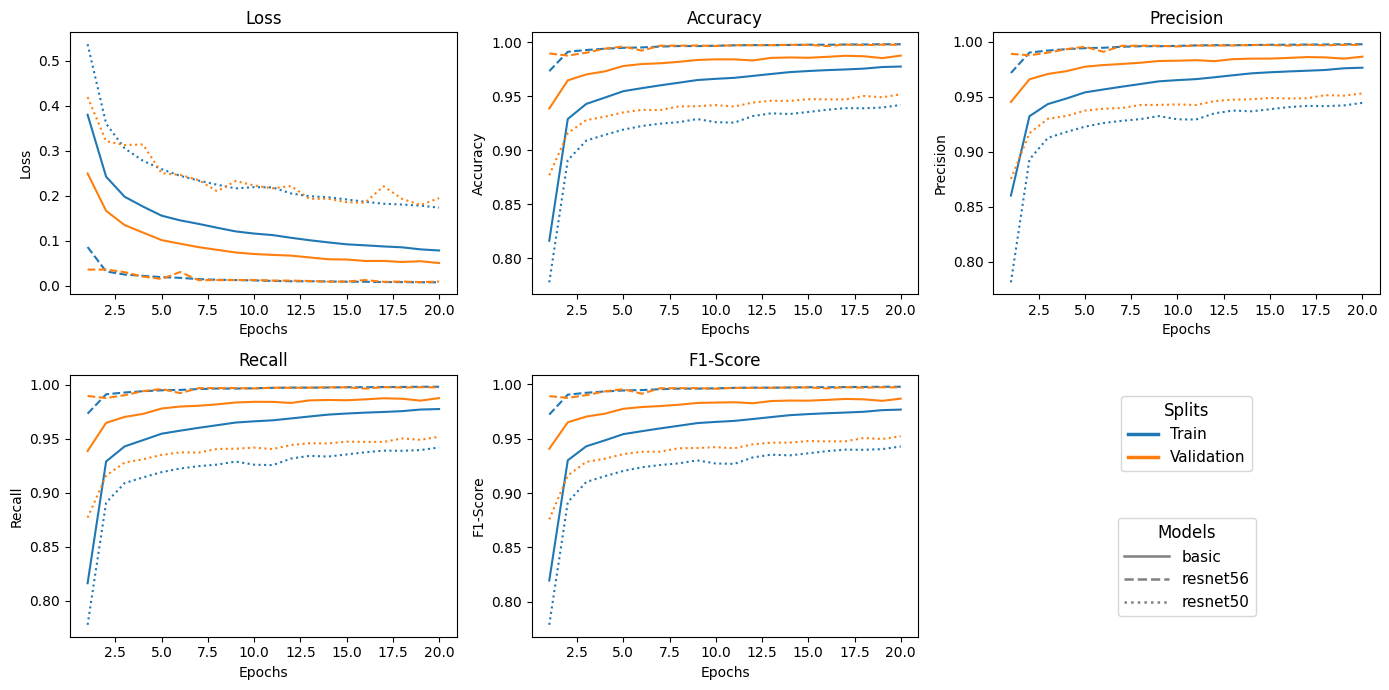

In [24]:
from matplotlib.lines import Line2D

metrics_to_plot = [
    ("loss", "Loss"),
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score")
]

# Line style per model, color per split
linestyles   = ['-', '--', ':', '-.']
model_styles = {model: linestyles[i % len(linestyles)] for i, model in enumerate(MODELS)}
split_colors = {'train': 'C0', 'val': 'C1'}
split_names  = {'train': 'Train', 'val': 'Validation'}

fig, axes = plt.subplots(2, 3, figsize=(14,7))
axes = axes.flatten()

for i, (metric_key, metric_title) in enumerate(metrics_to_plot):
    ax = axes[i]

    for model in MODELS:
        train_values = results_metrics[model][f'train_{metric_key}']
        val_values   = results_metrics[model][f'val_{metric_key}']
        epochs       = range(1, len(train_values) + 1)

        ax.plot(epochs, train_values, color=split_colors['train'], linestyle=model_styles[model])
        ax.plot(epochs, val_values,   color=split_colors['val'],   linestyle=model_styles[model])
    ax.set_xlabel('Epochs')
    ax.set_ylabel(metric_title)
    ax.set_title(f'{metric_title}')

axes[5].axis('off')

# Leyenda: colores = splits, estilos de línea = modelos
split_handles = [Line2D([0], [0], color=split_colors[s], lw=2.5, label=split_names[s]) for s in split_colors]
model_handles = [Line2D([0], [0], color='gray', lw=1.8, linestyle=model_styles[m], label=m) for m in MODELS]

leg_splits = axes[5].legend(handles=split_handles, loc='upper center', bbox_to_anchor=(0.5, 0.95),
                            fontsize=11, frameon=True, title="Splits", title_fontsize=12)
axes[5].add_artist(leg_splits)
axes[5].legend(handles=model_handles, loc='lower center', bbox_to_anchor=(0.5, 0.05),
               fontsize=11, frameon=True, title="Models", title_fontsize=12, handlelength=3)

# Imprimir resumen de los valores finales en consola
for model in MODELS:
    print(f"\n================= {model.upper()} Final Epoch Results =================")
    for metric_key, metric_title in metrics_to_plot:
        final_tr  = results_metrics[model][f'train_{metric_key}'][-1]
        final_val = results_metrics[model][f'val_{metric_key}'][-1]
        print(f"{metric_title:<10} | Train: {final_tr:.4f} | Val: {final_val:.4f}")

plt.tight_layout()
plt.savefig('metrics.png', dpi=300)
files.download('metrics.png')
plt.show()

Here we present the confusion matrix for each evaluated model on the unseen test set.
  
This allows us to evaluate the balance between:
* **True Positives (TP):** Real/synthetic moving objects correctly identified.
* **False Positives (FP):** Background noise fluctuations or reduction artifacts incorrectly classified as real sources.
* **False Negatives (FN):** Genuine sources missed by the classifier(critical in survey searches).

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

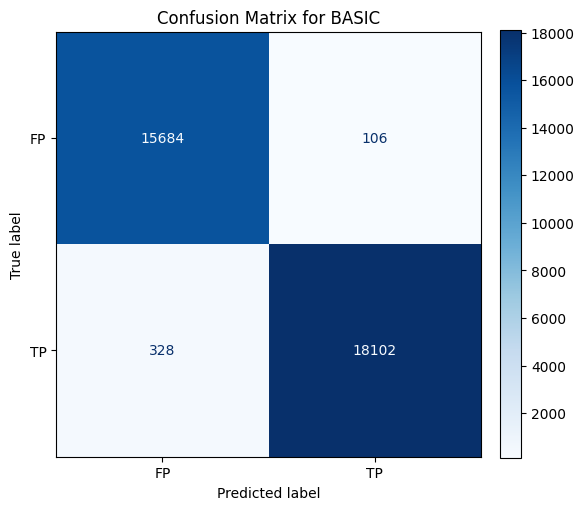

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

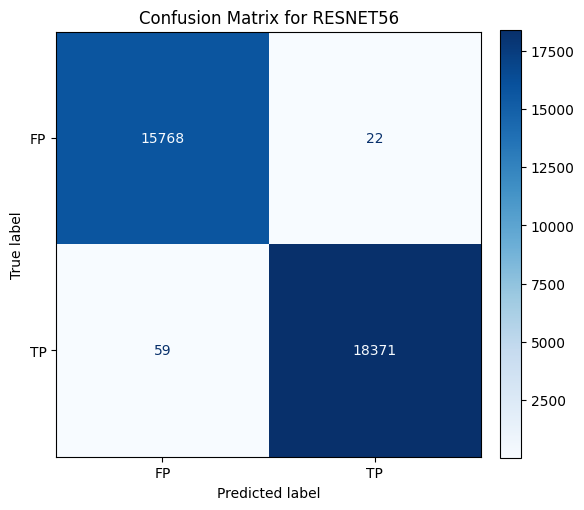

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

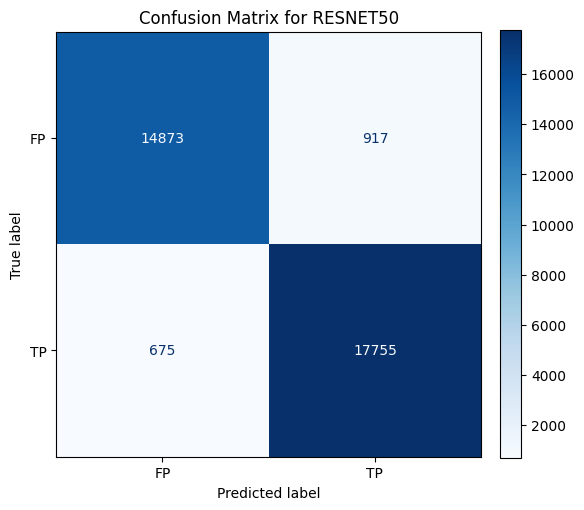

In [26]:
for model in MODELS:
    fig, ax = plt.subplots(figsize=(6, 6))
    cm   = results_predictions[model]['confusion_matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FP", "TP"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    fig.colorbar(disp.im_, ax=ax, fraction=0.046, pad=0.04)
    plt.title(f"Confusion Matrix for {model.upper()}")
    plt.savefig(f'confusion_matrix_{model}.png', dpi=300)
    files.download(f'confusion_matrix_{model}.png')
    plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

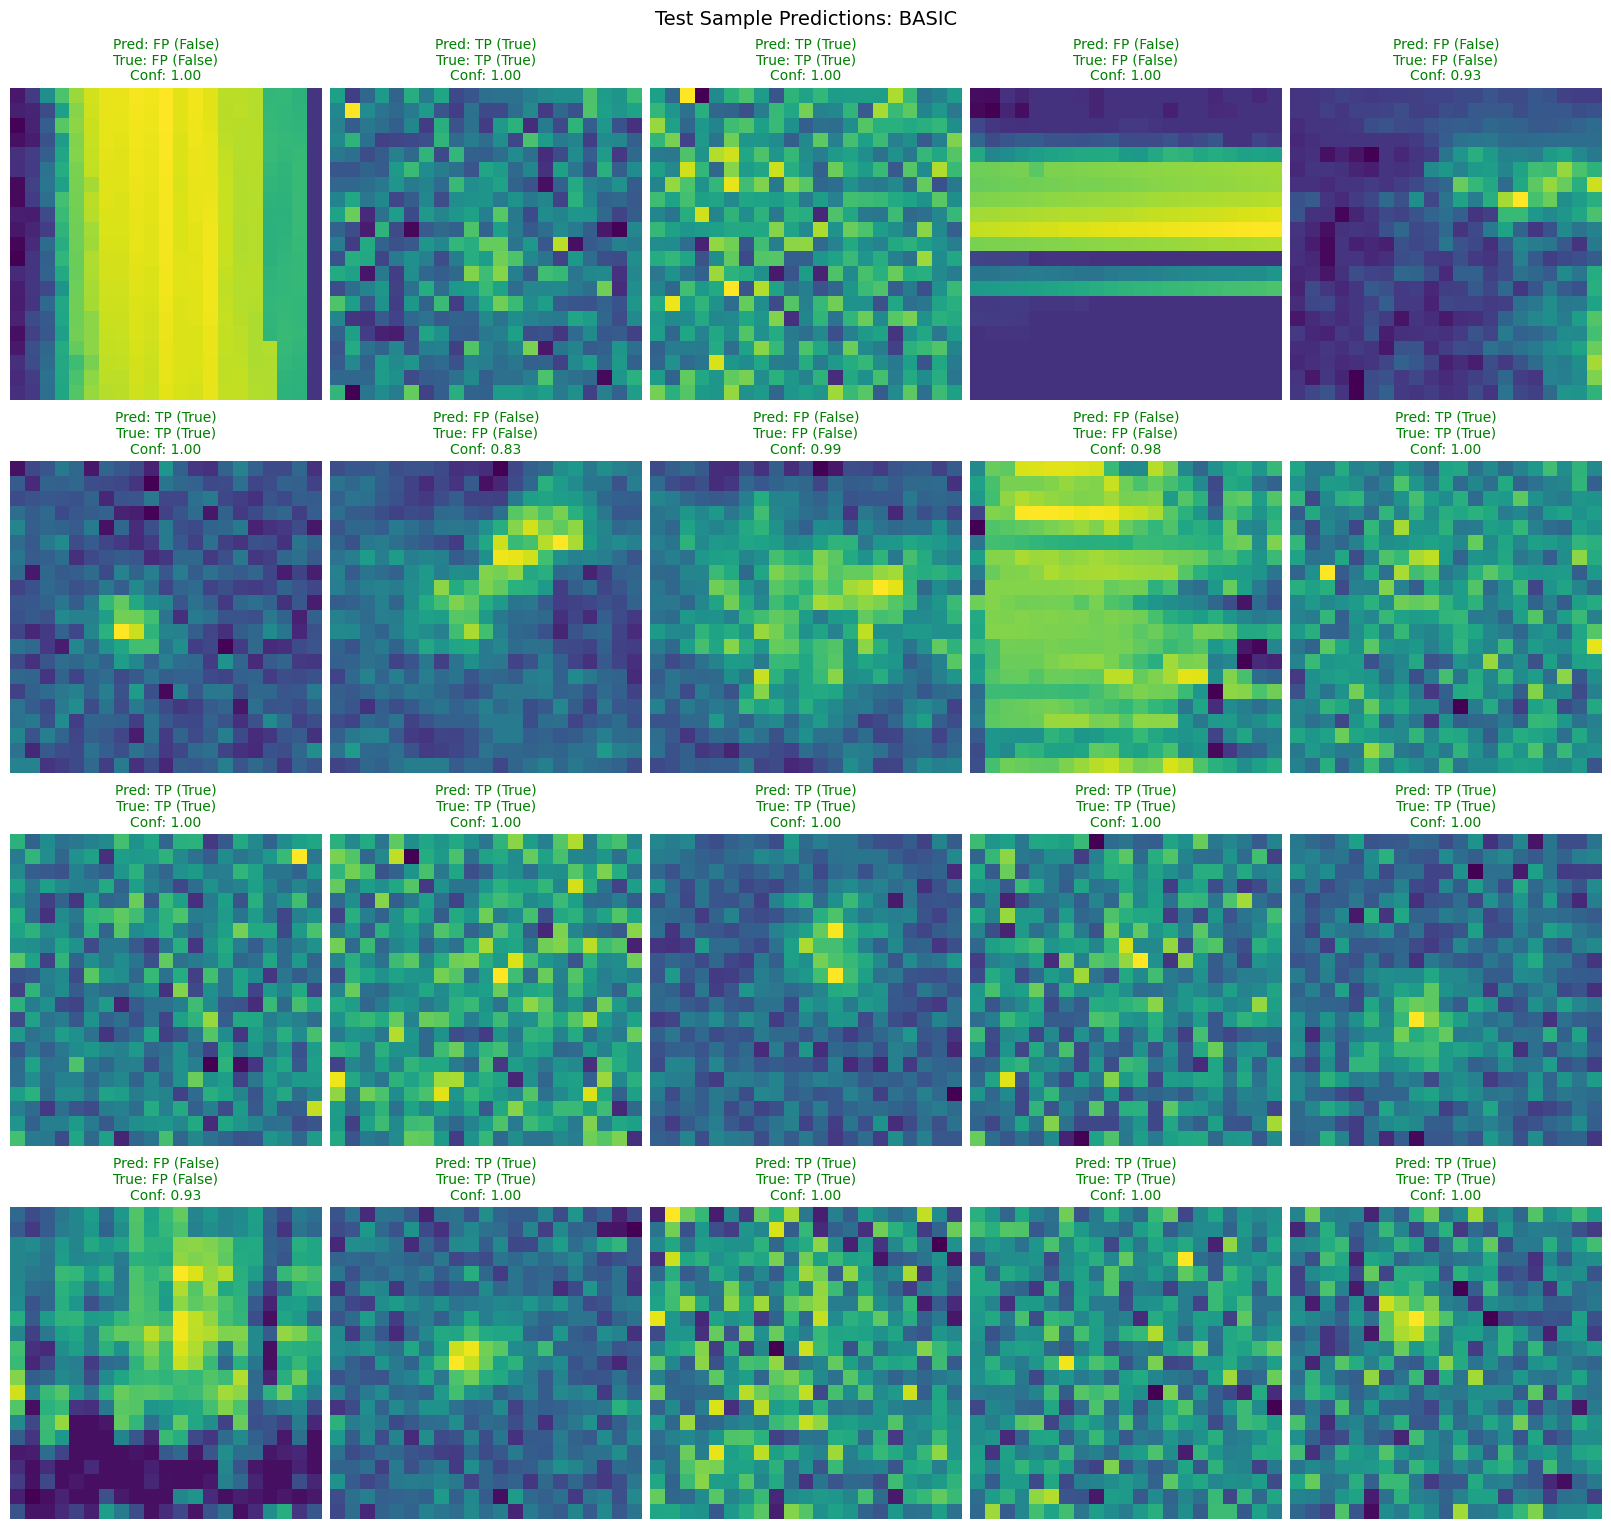

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

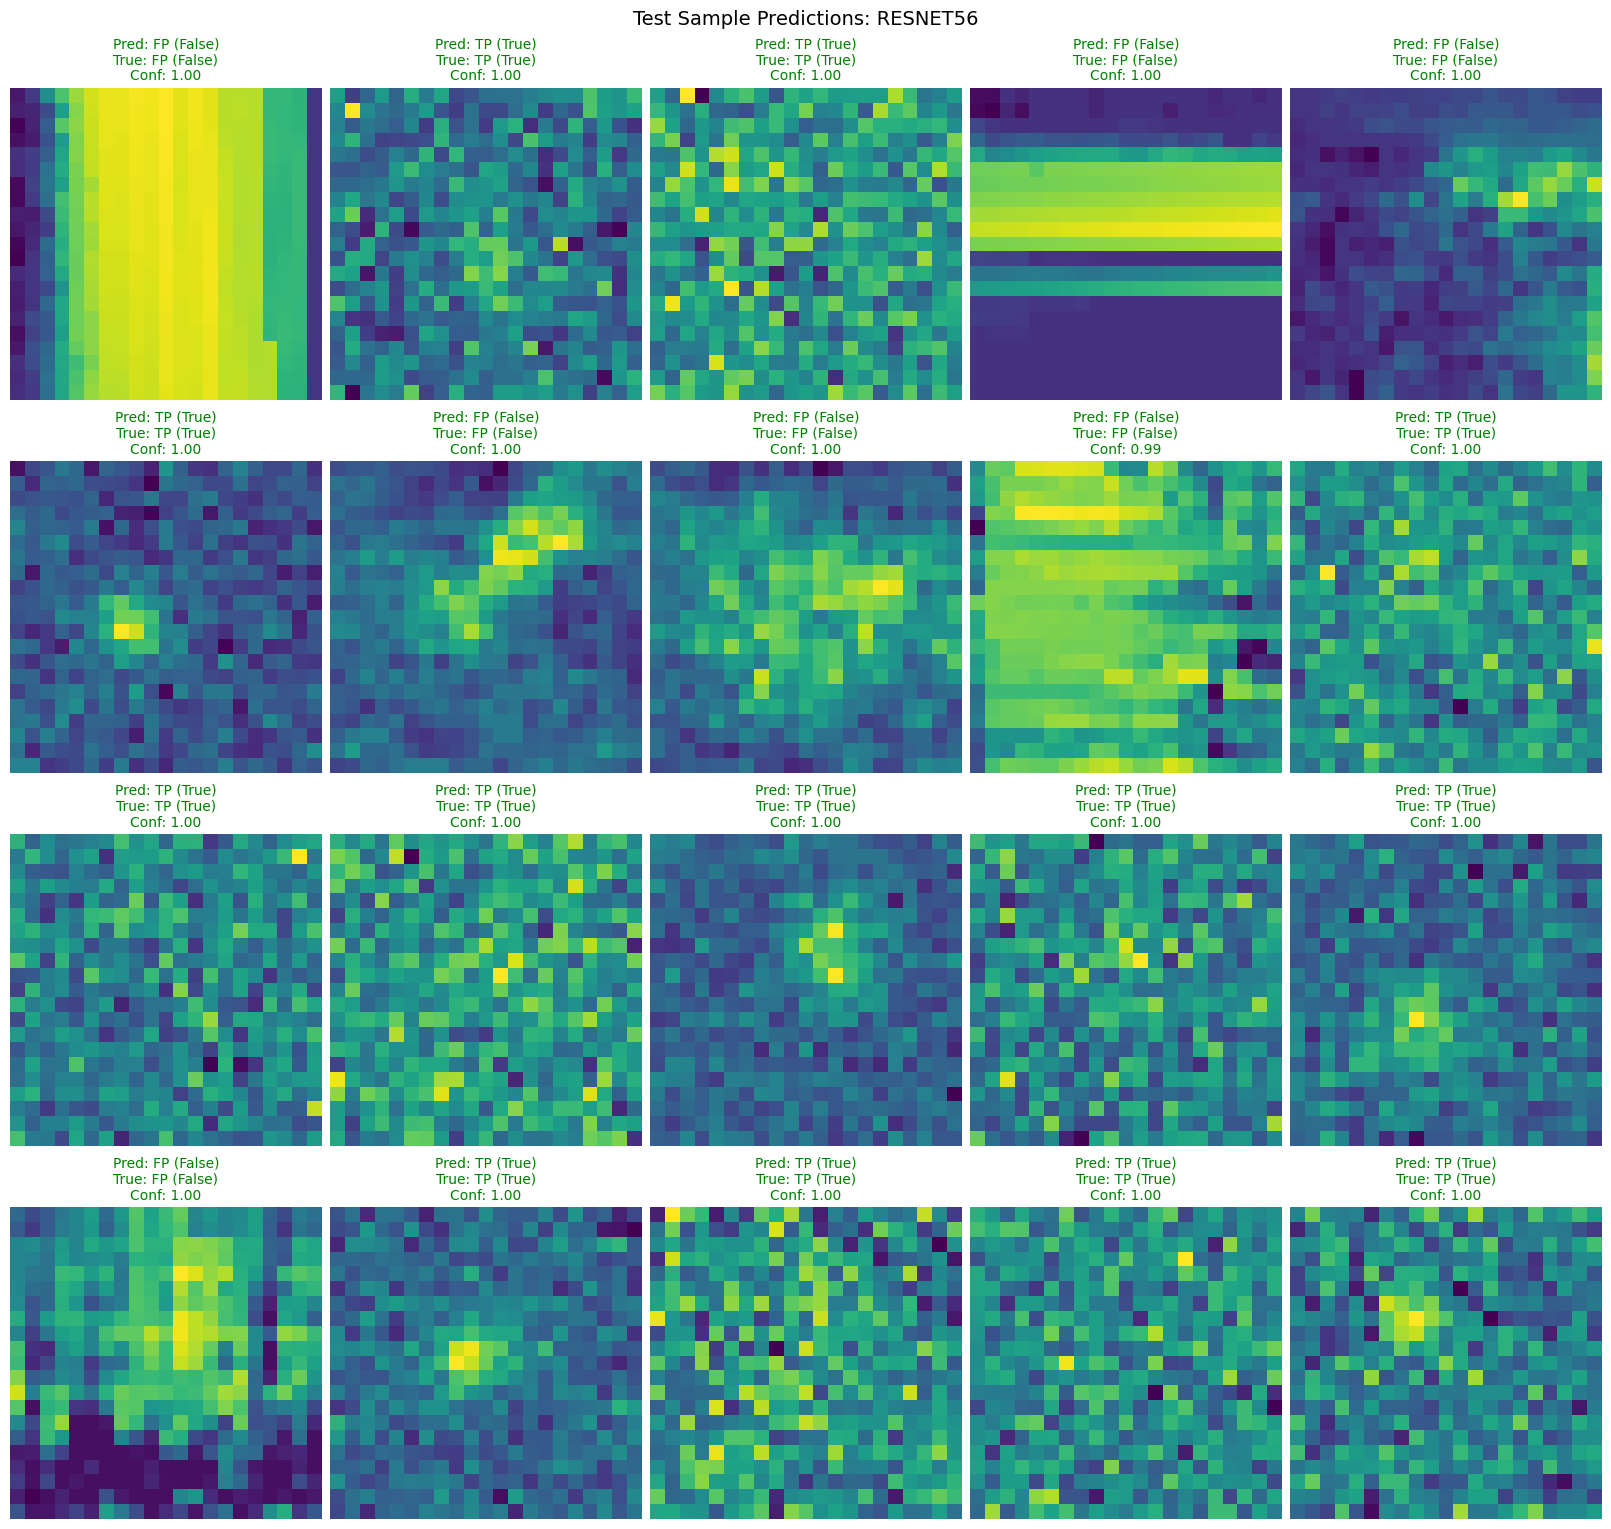

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

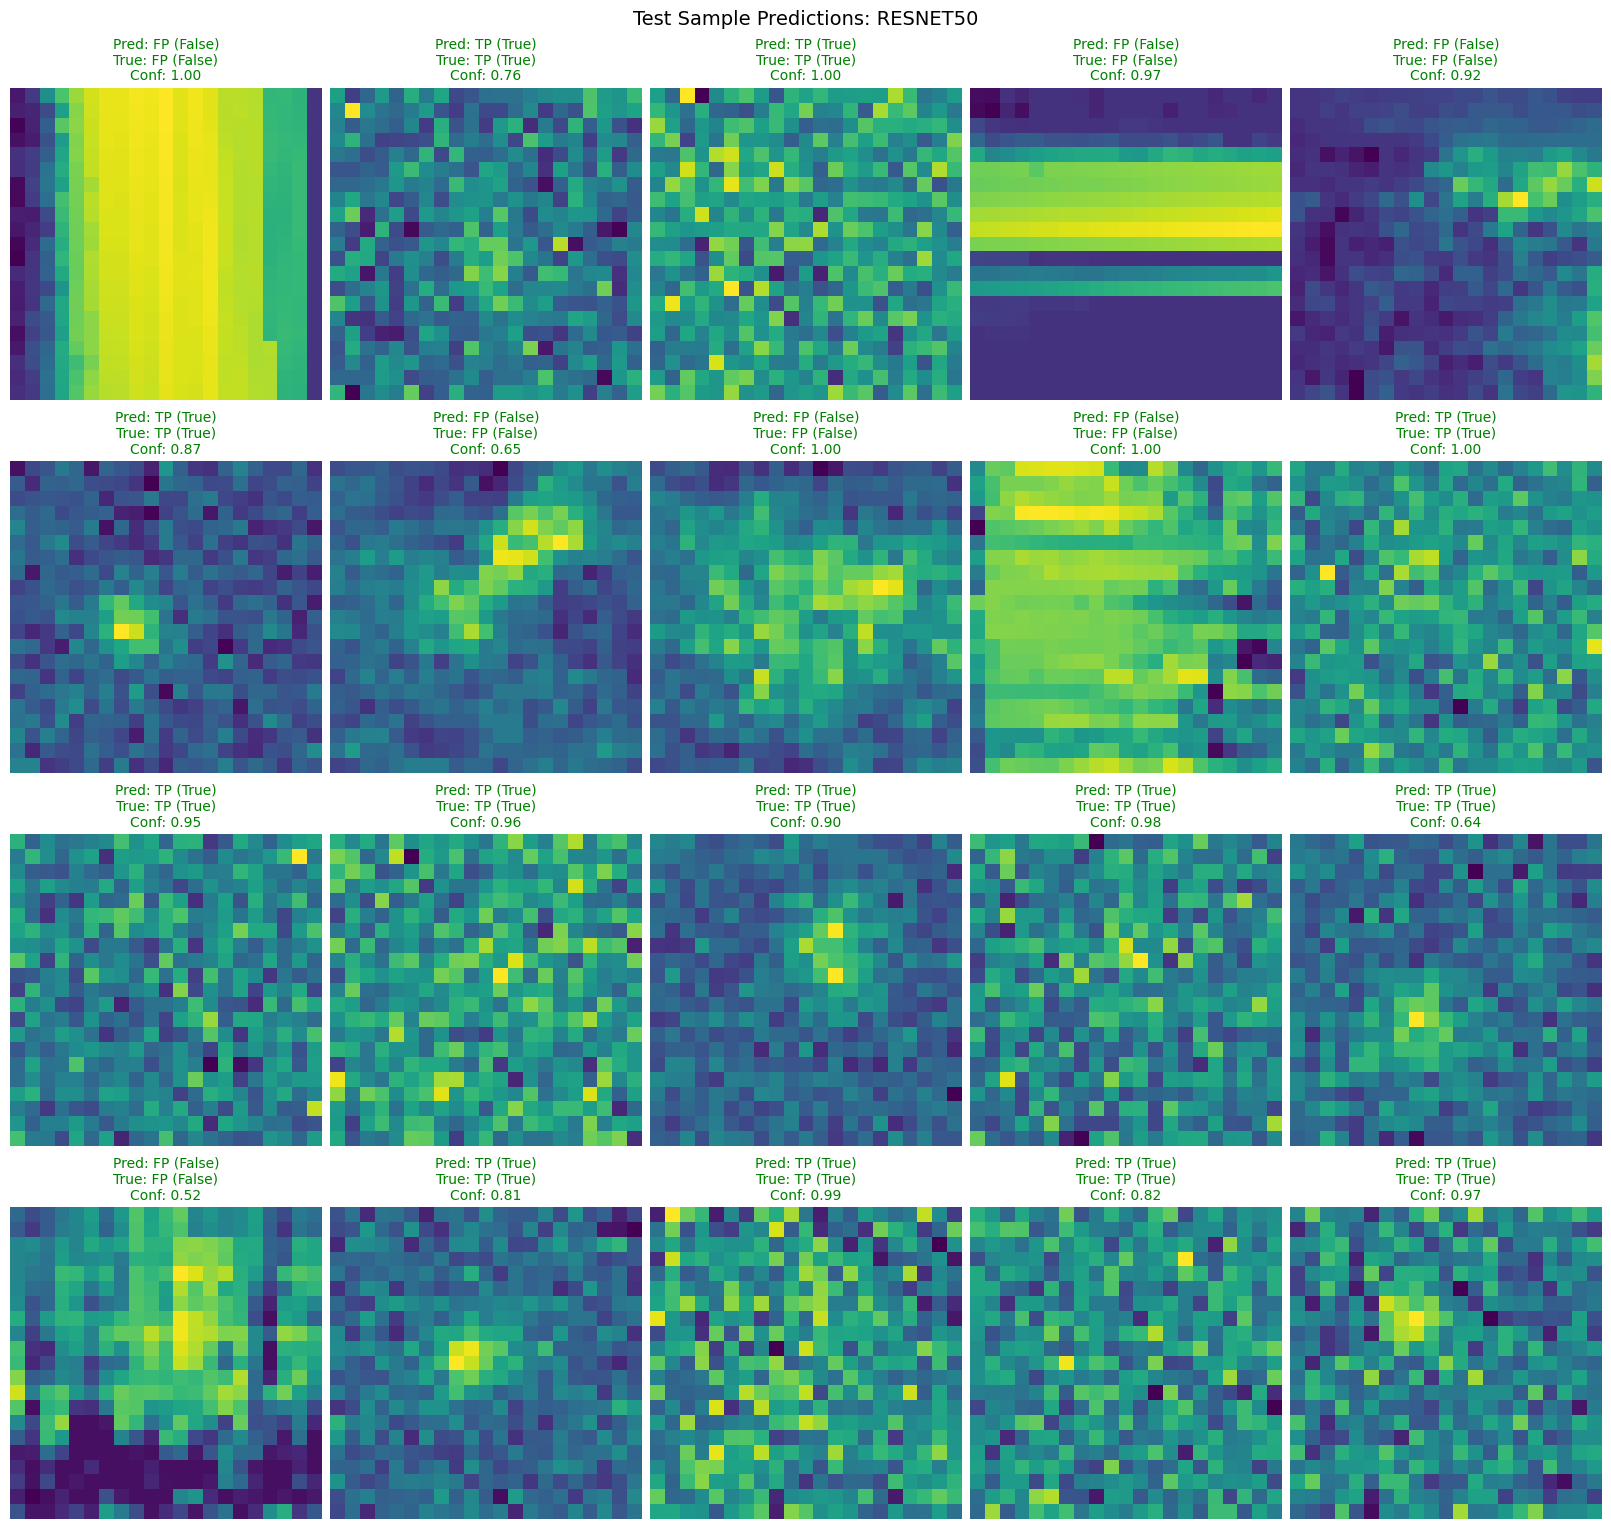

In [31]:
n = 20
num_cols = 5; num_rows = (n + num_cols - 1) // num_cols

total_test  = len(results_predictions[MODELS[1]]['true_labels'])
random_indx = np.random.choice(total_test, size=n, replace=False)

test_dataset = test_dataloader.dataset

class_names = {0: "FP (False)", 1: "TP (True)"}

for model in MODELS:
    fig, ax = plt.subplots(
        nrows=num_rows, ncols=num_cols,
        figsize=(16, 3.8 * num_rows),
        layout="constrained",
    )
    fig.suptitle(f'Test Sample Predictions: {model.upper()}', fontsize=14)
    ax = ax.flatten()

    # Retrieve the probabilities for the current model
    probs = results_predictions[model]['probabilities']
    preds = results_predictions[model]['predictions']
    trues = results_predictions[model]['true_labels']

    for i, idx in enumerate(random_indx):
        img, _ = test_dataset[idx]
        pred_class = int(preds[idx])
        true_class = int(trues[idx])
        conf       = probs[idx][pred_class]

        title_color = "green" if pred_class == true_class else "red"

        ax[i].imshow(img.squeeze().cpu().numpy(), cmap='viridis')
        ax[i].set_title(
             f"Pred: {class_names[pred_class]}\nTrue: {class_names[true_class]}\nConf: {conf:.2f}",
            color=title_color, fontsize=10,
        )
        ax[i].axis("off")

    for j in range(n, len(ax)):
        ax[j].axis("off")

    plt.savefig(f'test_predictions_{model}.png', dpi=300)
    files.download(f'test_predictions_{model}.png')
    plt.show()